In [36]:
import pandas as pd

# Load dataset
df = pd.read_csv("customer_shopping_data.csv")

# View first 5 rows
df.head()



,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [37]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [38]:
df.isnull().sum()


,0
invoice_no,0
customer_id,0
gender,0
age,0
category,0
quantity,0
price,0
payment_method,0
invoice_date,0
shopping_mall,0


In [39]:
df = df.drop_duplicates()


In [40]:
rfm = df.groupby("customer_id").agg({
    "invoice_no": "count",      # Frequency
    "price": "sum"              # Monetary
}).reset_index()

rfm.columns = ["CustomerID", "Frequency", "Monetary"]
rfm.head()


,CustomerID,Frequency,Monetary
0,C100004,1,1500.40
1,C100005,1,1200.34
2,C100006,1,107.52
3,C100012,1,26.15
4,C100019,1,35.84


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Frequency", "Monetary"]])


In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()


,CustomerID,Frequency,Monetary,Cluster
0,C100004,1,1500.40,1
1,C100005,1,1200.34,1
2,C100006,1,107.52,0
3,C100012,1,26.15,0
4,C100019,1,35.84,0


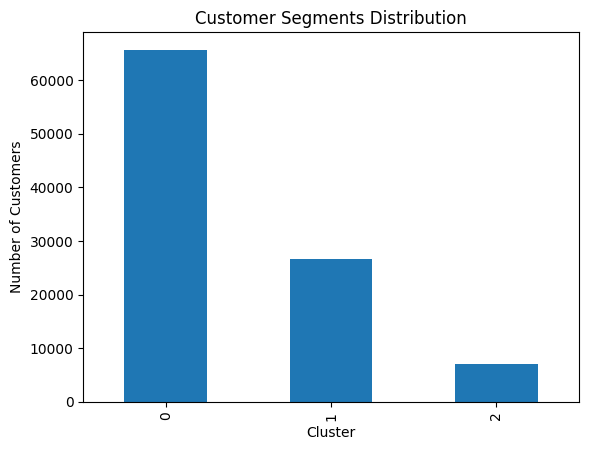

In [43]:
import matplotlib.pyplot as plt

rfm["Cluster"].value_counts().plot(kind="bar")
plt.title("Customer Segments Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


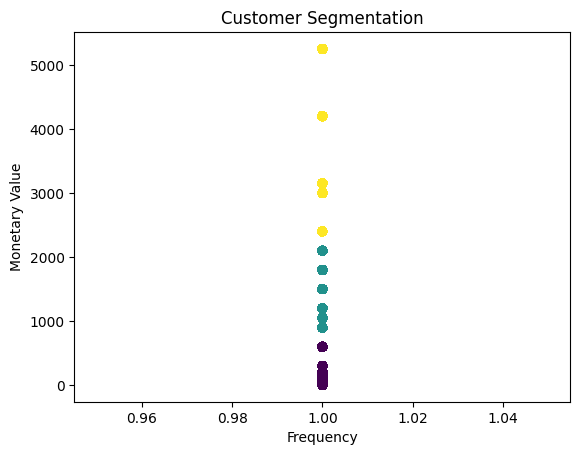

In [44]:
plt.scatter(rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"])
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.title("Customer Segmentation")
plt.show()
